In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
customer_df = pd.read_csv('./Telco-Customer-Churn.csv')
customer_df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
round(customer_df.describe(include = 'all').T,2)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# checking for null values
customer_df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
# dropping customer_id because it is not required
customer_df.drop("customerID",axis = 1, inplace = True)

In [7]:
col = customer_df.columns
customer_df[col] = customer_df[col].replace({
    'No internet service': 'No',
    'No phone service': 'No',
    'No internet service': 'No'
})

In [8]:
# checking columns for 'yes' and 'no' as value and mapping those columns
columns = customer_df.columns
for cols in columns :
    if set(customer_df[cols].dropna().unique()) == {'Yes', 'No'}:
       mapping_code = {'Yes' : 1, 'No' : 0}
       customer_df[cols] = customer_df[cols].map(mapping_code)

In [9]:
# checking the rest of the columns
categorical_cols = customer_df.select_dtypes(include = 'object').columns.tolist()

for col in categorical_cols:
    unique = customer_df[col].unique()
    print(f"-----Columns----- : {col}")
    print(f"--Unique Value--:{unique}")
    print("\n")

-----Columns----- : gender
--Unique Value--:['Female' 'Male']


-----Columns----- : InternetService
--Unique Value--:['DSL' 'Fiber optic' 'No']


-----Columns----- : Contract
--Unique Value--:['Month-to-month' 'One year' 'Two year']


-----Columns----- : PaymentMethod
--Unique Value--:['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


-----Columns----- : TotalCharges
--Unique Value--:['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']




In [10]:
# mapping gender
customer_df['gender'] = customer_df['gender'].map({'Male' : 1, 'Female' : 0})

In [11]:
# converting total charges into integar value
customer_df['TotalCharges'] = pd.to_numeric(customer_df['TotalCharges'], errors='coerce')

In [12]:
customer_df['TotalCharges'].isna().sum()

np.int64(11)

<Axes: >

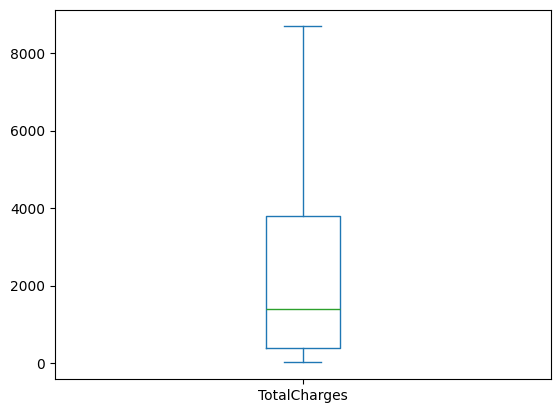

In [13]:
customer_df['TotalCharges'].plot(kind = 'box')

In [14]:
customer_df['TotalCharges'] = customer_df['TotalCharges'].fillna(customer_df['TotalCharges'].mean())

In [15]:
from sklearn.preprocessing import OneHotEncoder

e_columns = ['Contract','PaymentMethod','InternetService']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded_data = encoder.fit_transform(customer_df[e_columns])
encoded_cols = encoder.get_feature_names_out(e_columns)

encoded_df = pd.DataFrame(encoded_data, columns=encoded_cols)

customer_df = pd.concat([customer_df, encoded_df], axis=1)
customer_df.drop(e_columns, axis=1, inplace=True)

In [16]:
customer_df['Churn'].value_counts(normalize=True) * 100

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

In [30]:
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score,cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay,accuracy_score,roc_auc_score,auc,roc_curve,classification_report

* FINDING THE DEPTH OF THE DECISION TREE THEN TRAINING VARIOUS MODEL USING THE TRAIN-TEST-SPLIT

In [19]:
X = customer_df.drop('Churn',axis = 1)
y = customer_df['Churn']
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.25)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5282, 26)
(1761, 26)
(5282,)
(1761,)


In [20]:
def depth(md):
    model = DecisionTreeClassifier(max_depth=md,random_state=42)
    model.fit(X_train,y_train)
    train_error = 1 - model.score(X_train,y_train)
    test_error = 1 - model.score(X_test,y_test)
    return {
        'Max_depth' : md,
        'Train Error' : train_error,
        'Test Error' : test_error
    }
error = pd.DataFrame([
    depth(md)
    for md in range(1,21)
])
error

,Max_depth,Train Error,Test Error
0,1,0.263158,0.272005
1,2,0.241007,0.227144
2,3,0.208633,0.212947
3,4,0.206929,0.216922
4,5,0.198788,0.213515
5,6,0.191215,0.215219
6,7,0.175691,0.212947
7,8,0.161681,0.226008
8,9,0.141234,0.220329
9,10,0.123438,0.237365


In [23]:
def train_model_tts(model, X, y):

    if model == "RandomForestClassifier":

        pipe = Pipeline([
            ('smote', SMOTE(random_state=42)),
            ('model', RandomForestClassifier(
                random_state=42,
                n_jobs=-1,
                max_depth=5,
                n_estimators=100
            ))
        ])

    elif model == "DecisionTreeClassifier":

        pipe = Pipeline([
            ('smote', SMOTE(random_state=42)),
            ('model', DecisionTreeClassifier(
                random_state=42,
                max_depth=4
            ))
        ])

    elif model == "XGBClassifier":

        pipe = Pipeline([
            ('smote', SMOTE(random_state=42)),
            ('model', XGBClassifier(
                random_state=42
            ))
        ])

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        random_state=42,
        test_size=0.25,
        stratify=y
    )

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"Model : {model}")
    print(f"Accuracy : {accuracy}")
    print("\n")
    ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
    plt.title(f"{model} - Confusion Matrix")
    plt.show()

    print("\n")
    print("Classification Report :",classification_report(y_test,y_pred))

    print("\n")
    print("ROC-AUC-SCORE")
    model_probs = pipe.predict_proba(X_test)[:,1]
    model_fpr, model_tpr, _ = roc_curve(y_test, model_probs)
    # auc
    model_auc = auc(model_fpr,model_tpr)
    print(f"{model} AUC : {model_auc:.4f}")

    # visualize
    plt.figure(figsize=(8,6))
    plt.plot(model_fpr,model_tpr,color='blue',lw=2, label = f"model_auc = {model_auc:2f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC-CURVE")
    plt.legend(loc = 'lower right')
    plt.grid(True,alpha = 0.3)
    plt.tight_layout()
    plt.show()


In [24]:
X = customer_df.drop('Churn',axis = 1)
y = customer_df['Churn']

print(X.shape)
print(y.shape)

(7043, 26)
(7043,)


Model : DecisionTreeClassifier
Accuracy : 0.7308347529812607




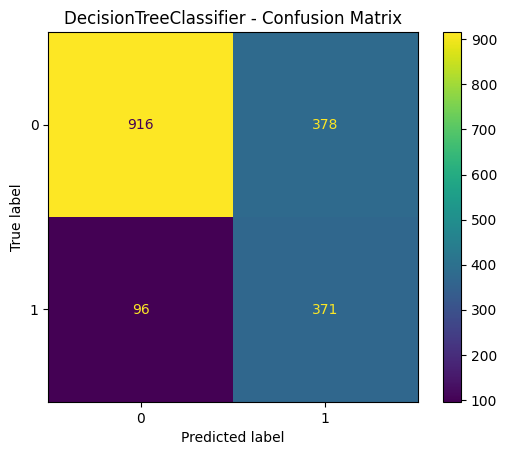



Classification Report :               precision    recall  f1-score   support

           0       0.91      0.71      0.79      1294
           1       0.50      0.79      0.61       467

    accuracy                           0.73      1761
   macro avg       0.70      0.75      0.70      1761
weighted avg       0.80      0.73      0.75      1761



ROC-AUC-SCORE
DecisionTreeClassifier AUC : 0.8122


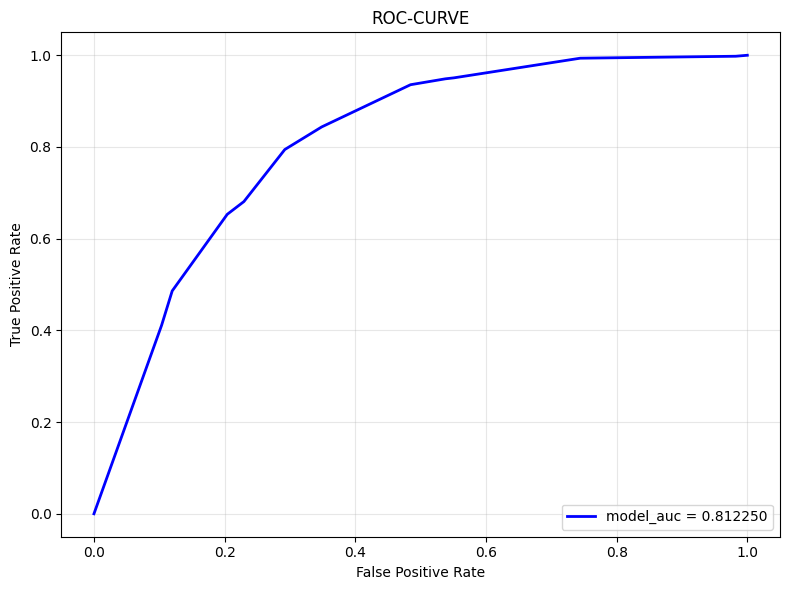

In [26]:
train_model_tts("DecisionTreeClassifier", X, y)

Model : XGBClassifier
Accuracy : 0.7819420783645656




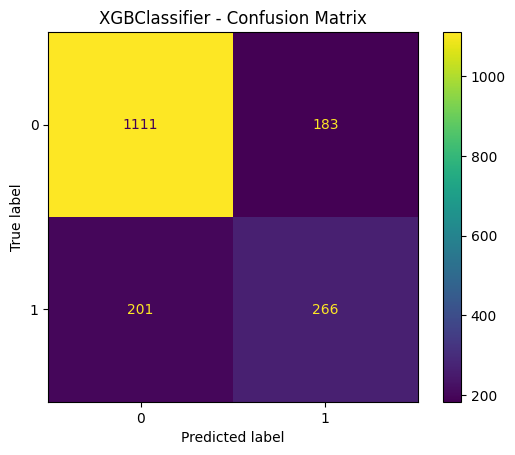



Classification Report :               precision    recall  f1-score   support

           0       0.85      0.86      0.85      1294
           1       0.59      0.57      0.58       467

    accuracy                           0.78      1761
   macro avg       0.72      0.71      0.72      1761
weighted avg       0.78      0.78      0.78      1761



ROC-AUC-SCORE
XGBClassifier AUC : 0.8210


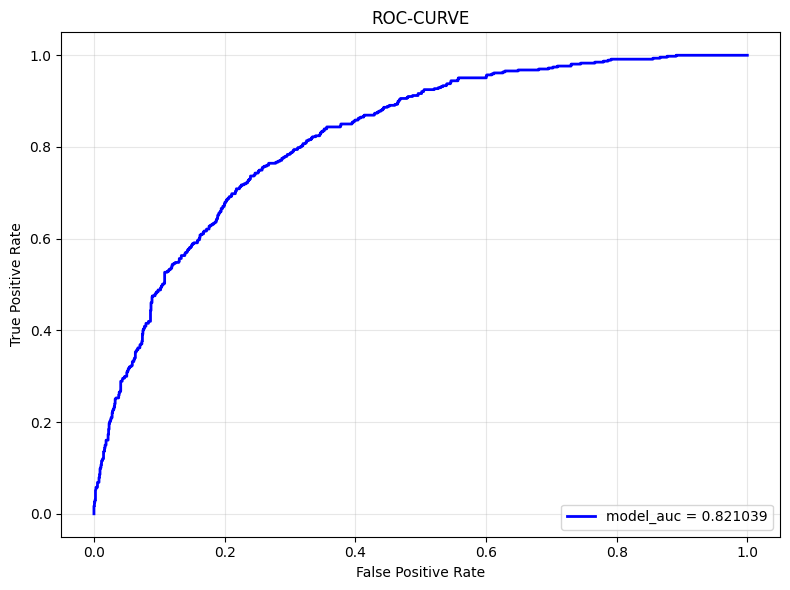

In [28]:
train_model_tts("XGBClassifier", X, y)

Model : RandomForestClassifier
Accuracy : 0.771152754116979




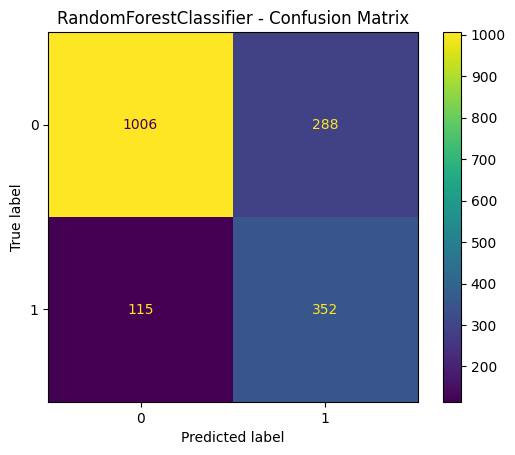



Classification Report :               precision    recall  f1-score   support

           0       0.90      0.78      0.83      1294
           1       0.55      0.75      0.64       467

    accuracy                           0.77      1761
   macro avg       0.72      0.77      0.73      1761
weighted avg       0.81      0.77      0.78      1761



ROC-AUC-SCORE
RandomForestClassifier AUC : 0.8385


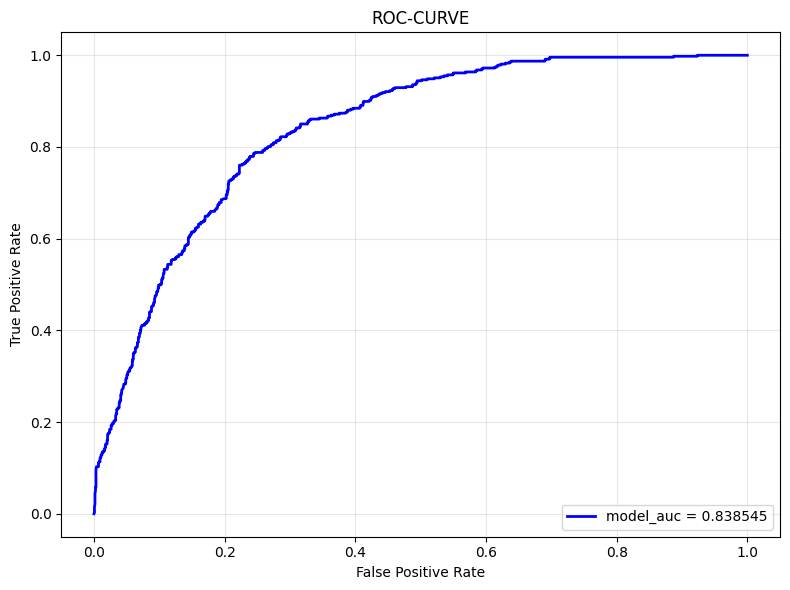

In [27]:
train_model_tts("RandomForestClassifier", X, y)

In [31]:
def train_model_kfold(model, X, y, n_splits=5):

    if model == "RandomForestClassifier":

        pipe = Pipeline([
            ('smote', SMOTE(random_state=42)),
            ('model', RandomForestClassifier(
                random_state=42,
                n_jobs=-1,
                max_depth=5,
                n_estimators=100
            ))
        ])

    elif model == "DecisionTreeClassifier":

        pipe = Pipeline([
            ('smote', SMOTE(random_state=42)),
            ('model', DecisionTreeClassifier(
                random_state=42,
                max_depth=4
            ))
        ])

    elif model == "XGBClassifier":

        pipe = Pipeline([
            ('smote', SMOTE(random_state=42)),
            ('model', XGBClassifier(
                random_state=42
            ))
        ])

    elif model == "LogisticRegression":

        pipe = Pipeline([
            ('smote', SMOTE(random_state=42)),
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                random_state=42,
                max_iter=1000
            ))
        ])

    else:
        raise ValueError(f"Unknown model: '{model}'")

    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    score = cross_val_score(pipe, X, y, cv=kf, scoring='f1_macro')
    y_pred = cross_val_predict(pipe, X, y, cv=kf)
    model_probs = cross_val_predict(pipe, X, y, cv=kf, method='predict_proba')[:, 1]

    accuracy = accuracy_score(y, y_pred)

    print(f"Model : {model}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Mean F1 (macro) : {np.mean(score):.4f} ± {np.std(score):.4f}")
    print("\n")
    ConfusionMatrixDisplay.from_predictions(y, y_pred)
    plt.title(f"{model} - Confusion Matrix")
    plt.show()

    print("\n")
    print("Classification Report :", classification_report(y, y_pred))

    print("\n")
    print("ROC-AUC-SCORE")
    model_fpr, model_tpr, _ = roc_curve(y, model_probs)
    model_auc = auc(model_fpr, model_tpr)
    print(f"{model} AUC : {model_auc:.4f}")

    plt.figure(figsize=(8, 6))
    plt.plot(model_fpr, model_tpr, color='blue', lw=2, label=f"model_auc = {model_auc:.4f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC-CURVE")
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Model : LogisticRegression
Accuracy : 0.7765
Mean F1 (macro) : 0.7250 ± 0.0117




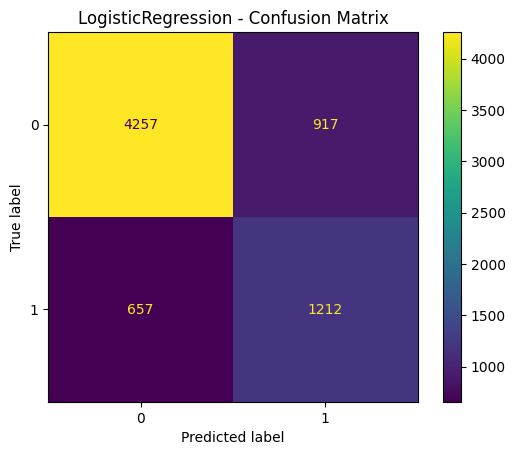



Classification Report :               precision    recall  f1-score   support

           0       0.87      0.82      0.84      5174
           1       0.57      0.65      0.61      1869

    accuracy                           0.78      7043
   macro avg       0.72      0.74      0.73      7043
weighted avg       0.79      0.78      0.78      7043



ROC-AUC-SCORE
LogisticRegression AUC : 0.8288


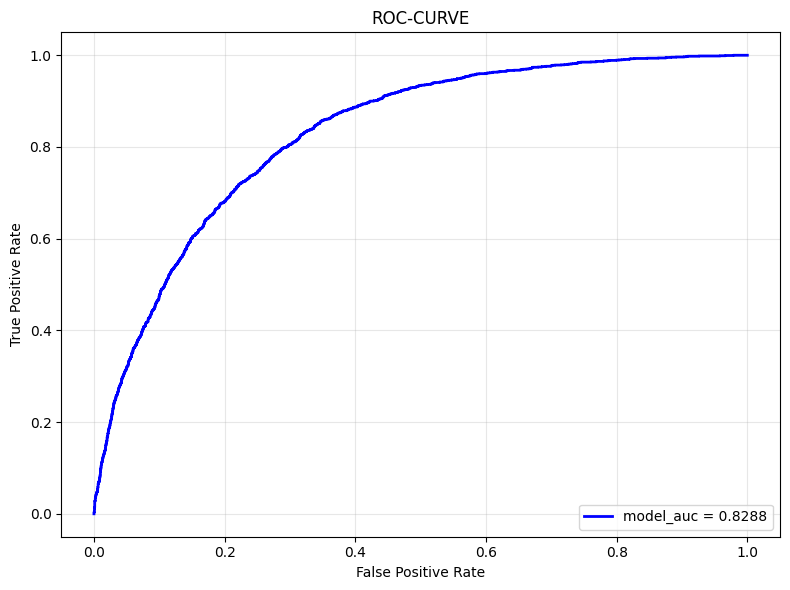

In [32]:
train_model_kfold("LogisticRegression",X,y)

Model : DecisionTreeClassifier
Accuracy : 0.7405
Mean F1 (macro) : 0.6989 ± 0.0065




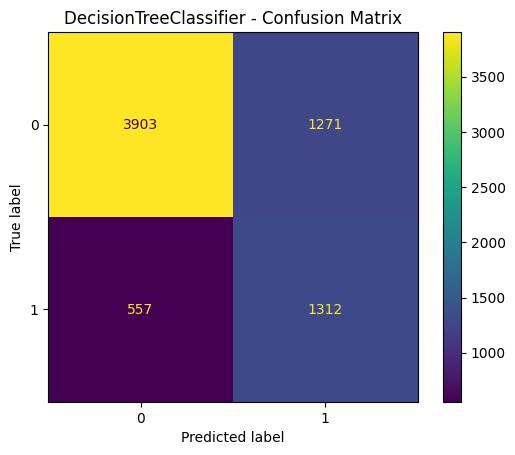



Classification Report :               precision    recall  f1-score   support

           0       0.88      0.75      0.81      5174
           1       0.51      0.70      0.59      1869

    accuracy                           0.74      7043
   macro avg       0.69      0.73      0.70      7043
weighted avg       0.78      0.74      0.75      7043



ROC-AUC-SCORE
DecisionTreeClassifier AUC : 0.8041


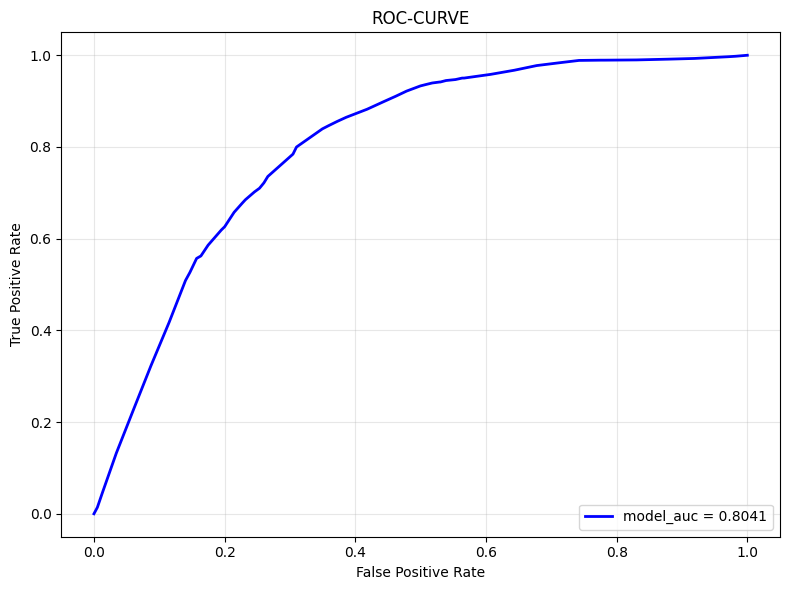

In [33]:
train_model_kfold("DecisionTreeClassifier",X,y)

Model : RandomForestClassifier
Accuracy : 0.7662
Mean F1 (macro) : 0.7291 ± 0.0074




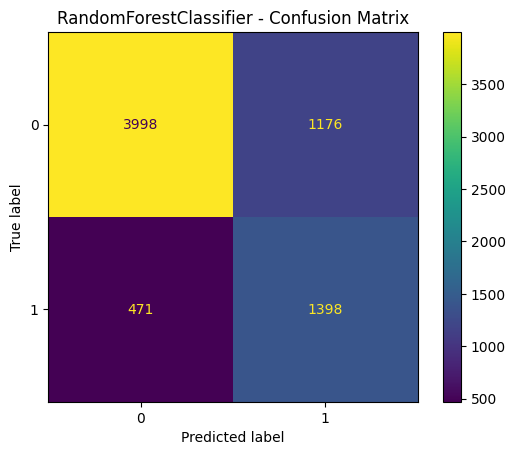



Classification Report :               precision    recall  f1-score   support

           0       0.89      0.77      0.83      5174
           1       0.54      0.75      0.63      1869

    accuracy                           0.77      7043
   macro avg       0.72      0.76      0.73      7043
weighted avg       0.80      0.77      0.78      7043



ROC-AUC-SCORE
RandomForestClassifier AUC : 0.8361


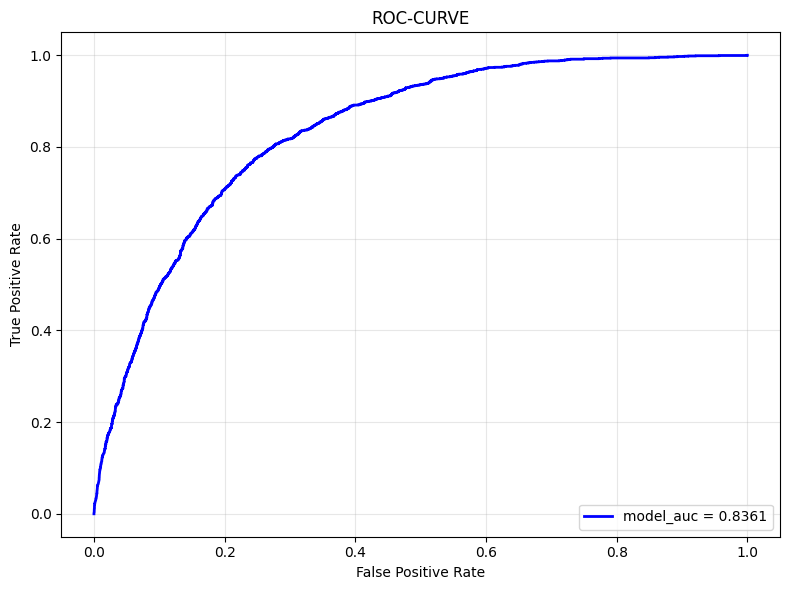

In [34]:
train_model_kfold("RandomForestClassifier",X,y)

Model : XGBClassifier
Accuracy : 0.7777
Mean F1 (macro) : 0.7133 ± 0.0121




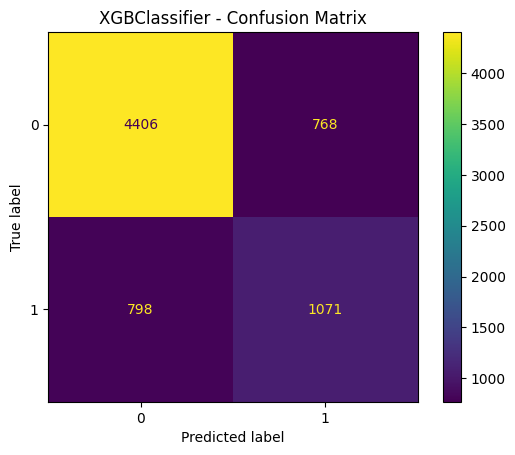



Classification Report :               precision    recall  f1-score   support

           0       0.85      0.85      0.85      5174
           1       0.58      0.57      0.58      1869

    accuracy                           0.78      7043
   macro avg       0.71      0.71      0.71      7043
weighted avg       0.78      0.78      0.78      7043



ROC-AUC-SCORE
XGBClassifier AUC : 0.8195


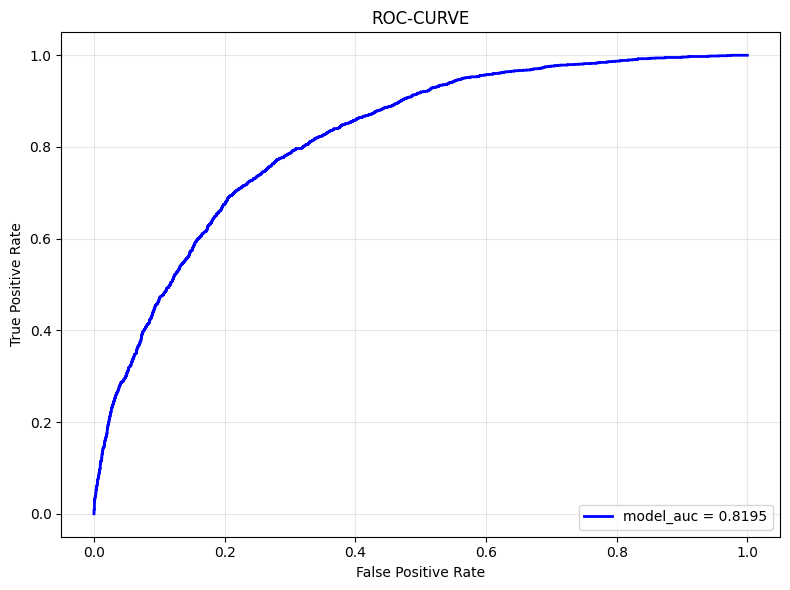

In [35]:
train_model_kfold("XGBClassifier",X,y)

In [36]:
def compare_models(X, y):

    models = ["LogisticRegression", "DecisionTreeClassifier", "RandomForestClassifier", "XGBClassifier"]
    results = []

    for model_name in models:

        if model_name == "RandomForestClassifier":
            pipe = Pipeline([('smote', SMOTE(random_state=42)), ('model', RandomForestClassifier(random_state=42, n_jobs=-1, max_depth=5, n_estimators=100))])

        elif model_name == "DecisionTreeClassifier":
            pipe = Pipeline([('smote', SMOTE(random_state=42)), ('model', DecisionTreeClassifier(random_state=42, max_depth=4))])

        elif model_name == "XGBClassifier":
            pipe = Pipeline([('smote', SMOTE(random_state=42)), ('model', XGBClassifier(random_state=42))])

        elif model_name == "LogisticRegression":
            pipe = Pipeline([('smote', SMOTE(random_state=42)), ('scaler', StandardScaler()), ('model', LogisticRegression(random_state=42, max_iter=1000))])

        # --- Train Test Split ---
        X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.25, stratify=y)
        pipe.fit(X_train, y_train)
        y_pred_tts = pipe.predict(X_test)
        probs_tts = pipe.predict_proba(X_test)[:, 1]
        tts_acc = accuracy_score(y_test, y_pred_tts)
        tts_f1 = classification_report(y_test, y_pred_tts, output_dict=True)['macro avg']['f1-score']
        fpr, tpr, _ = roc_curve(y_test, probs_tts)
        tts_auc = auc(fpr, tpr)

        # --- K-Fold ---
        kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        probs_kf = cross_val_predict(pipe, X, y, cv=kf, method='predict_proba')[:, 1]
        y_pred_kf = (probs_kf >= 0.5).astype(int)
        kf_acc = accuracy_score(y, y_pred_kf)
        kf_f1 = classification_report(y, y_pred_kf, output_dict=True)['macro avg']['f1-score']
        fpr, tpr, _ = roc_curve(y, probs_kf)
        kf_auc = auc(fpr, tpr)

        results.append({
            'Model'       : model_name,
            'TTS Acc'     : round(tts_acc, 4),
            'TTS F1'      : round(tts_f1, 4),
            'TTS AUC'     : round(tts_auc, 4),
            'KFold Acc'   : round(kf_acc, 4),
            'KFold F1'    : round(kf_f1, 4),
            'KFold AUC'   : round(kf_auc, 4),
        })

    results_df = pd.DataFrame(results).set_index('Model')
    print(results_df.to_string())
    print("\n")
    print(f"Best TTS AUC   : {results_df['TTS AUC'].idxmax()} ({results_df['TTS AUC'].max():.4f})")
    print(f"Best KFold AUC : {results_df['KFold AUC'].idxmax()} ({results_df['KFold AUC'].max():.4f})")
    print(f"Best TTS F1    : {results_df['TTS F1'].idxmax()} ({results_df['TTS F1'].max():.4f})")
    print(f"Best KFold F1  : {results_df['KFold F1'].idxmax()} ({results_df['KFold F1'].max():.4f})")

compare_models(X, y)

                        TTS Acc  TTS F1  TTS AUC  KFold Acc  KFold F1  KFold AUC
Model                                                                           
LogisticRegression       0.7825  0.7334   0.8343     0.7765    0.7251     0.8288
DecisionTreeClassifier   0.7308  0.7023   0.8122     0.7405    0.6998     0.8041
RandomForestClassifier   0.7712  0.7345   0.8385     0.7662    0.7293     0.8361
XGBClassifier            0.7819  0.7167   0.8210     0.7777    0.7134     0.8195


Best TTS AUC   : RandomForestClassifier (0.8385)
Best KFold AUC : RandomForestClassifier (0.8361)
Best TTS F1    : RandomForestClassifier (0.7345)
Best KFold F1  : RandomForestClassifier (0.7293)
